In [12]:
import pandas as pd
df = pd.read_excel('/content/Dataset for Data Analytics.xlsx')
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [13]:
(df['ItemsInCart'] < df['Quantity']).sum()

np.int64(0)

In [14]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


In [15]:
df['TotalPrice'].skew()

np.float64(0.8913590826809059)

In [16]:
df[['Quantity', 'UnitPrice', 'ItemsInCart']].skew()

,0
Quantity,0.027922
UnitPrice,-0.026512
ItemsInCart,0.000877


In [17]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", round(lower, 2))
print("Upper bound:", round(upper, 2))
print("Outliers:", ((df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)).sum())

Lower bound: -1341.41
Upper bound: 3330.41
Outliers: 8


In [18]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

df[df['TotalPrice'] > upper][['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']]

,OrderID,Product,Quantity,UnitPrice,TotalPrice
107,ORD200107,Printer,5,670.75,3353.75
326,ORD200326,Laptop,5,670.48,3352.40
328,ORD200328,Tablet,5,674.04,3370.20
469,ORD200469,Chair,5,676.98,3384.90
632,ORD200632,Laptop,5,678.16,3390.80
789,ORD200789,Tablet,5,691.28,3456.40
1065,ORD201065,Printer,5,666.80,3334.00
1122,ORD201122,Monitor,5,678.19,3390.95


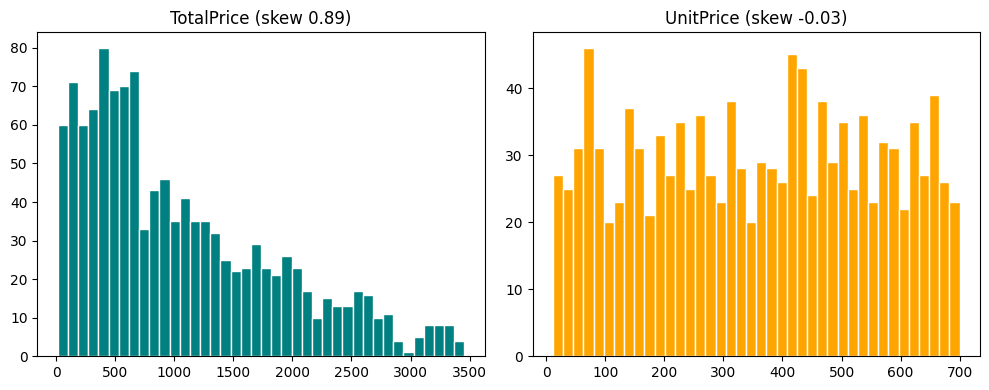

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['TotalPrice'], bins=40, color='teal', edgecolor='white')
plt.title('TotalPrice (skew 0.89)')

plt.subplot(1, 2, 2)
plt.hist(df['UnitPrice'], bins=40, color='orange', edgecolor='white')
plt.title('UnitPrice (skew -0.03)')

plt.tight_layout()
plt.show()

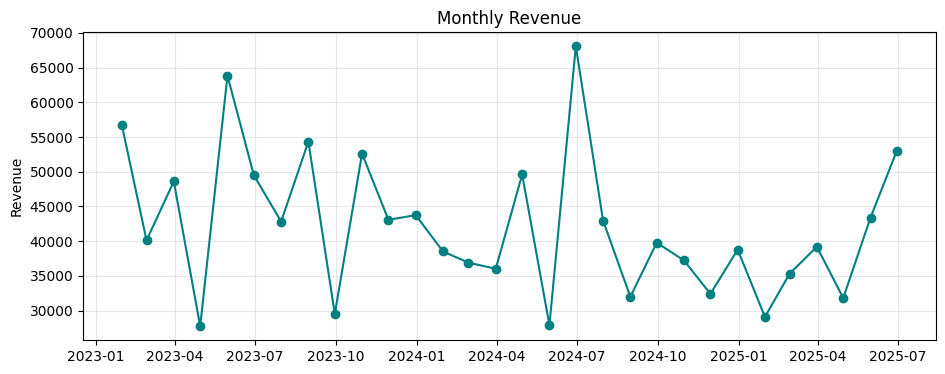

In [20]:
monthly = df.set_index('Date')['TotalPrice'].resample('ME').sum()

plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly.values, marker='o', color='teal')
plt.title('Monthly Revenue')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.show()

Problem Statement
Can this dataset be used for business decisions?

Methodology
I used descriptive statistics, distribution shape, IQR outlier
detection, correlation and monthly trend analysis, using Python
and pandas.

Key Findings
- UnitPrice has a uniform distribution (skew -0.03), which is not
  possible for real pricing.
- Quantity and ItemsInCart are also almost perfectly symmetrical.
- The skew in TotalPrice (0.89) comes from mathematics, not from
  customer behaviour. TotalPrice is Quantity multiplied by UnitPrice,
  and multiplying two symmetrical values always produces a skew.
- Only one real correlation was found (0.650, between Quantity and
  ItemsInCart), and ItemsInCart is never lower than Quantity in any
  of the 1,200 rows, which suggests it was generated by a rule.
- Monthly revenue shows no trend, only noise.

Recommendations
- Do not use this data for pricing, revenue forecasting or customer
  segmentation.
- This data is suitable for technical practice only.
- Real transaction data is required for real analysis.